In [2]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from database import get_engine

plt.style.use('seaborn-v0_8-darkgrid')
print("Imports Successful")

Imports Successful


In [3]:
engine = get_engine()

factors_df = pd.read_sql("""
    SELECT *
    FROM factors
    ORDER BY ticker, date
""", engine)

factors_df['date'] = pd.to_datetime(factors_df['date'])

print(f"Loaded {len(factors_df):,} rows")
print(f"Tickers: {sorted(factors_df['ticker'].unique())}")
print(f"Date range: {factors_df['date'].min().date()} to {factors_df['date'].max().date()}")
print(f"Columns: {list(factors_df.columns)}")

Loaded 37,725 rows
Tickers: ['AAPL', 'AMZN', 'BAC', 'GOOGL', 'GS', 'JNJ', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'SPY', 'UNH', 'V', 'XOM']
Date range: 2015-01-02 to 2024-12-30
Columns: ['date', 'ticker', 'close', 'daily_return', 'mom_12m', 'mom_6m', 'mom_1m', 'mom_5d', 'reversal', 'vol_21d', 'vol_63d', 'vol_ratio', 'volume_ratio', 'pvt', 'high_52w', 'dist_from_high', 'rsi']


In [4]:
def get_monthly_rebalance_dates(df):
    # Get the last trading day of each month for each ticker
    df['year_month'] = df['date'].dt.to_period('M')
    
    monthly_dates = (
        df.groupby('year_month')['date']
        .max()
        .reset_index()
    )
    
    monthly_dates.columns = ['year_month', 'rebalance_date']
    
    return monthly_dates

rebalance_dates = get_monthly_rebalance_dates(factors_df)

print(f"Total rebalancing periods: {len(rebalance_dates)}")
print(f"First rebalance: {rebalance_dates['rebalance_date'].iloc[0].date()}")
print(f"Last rebalance: {rebalance_dates['rebalance_date'].iloc[-1].date()}")
rebalance_dates.head(10)

Total rebalancing periods: 120
First rebalance: 2015-01-30
Last rebalance: 2024-12-30


,year_month,rebalance_date
0,2015-01,2015-01-30
1,2015-02,2015-02-27
2,2015-03,2015-03-31
3,2015-04,2015-04-30
4,2015-05,2015-05-29
5,2015-06,2015-06-30
6,2015-07,2015-07-31
7,2015-08,2015-08-31
8,2015-09,2015-09-30
9,2015-10,2015-10-30


In [5]:
FACTOR_WEIGHTS = {
    'mom_12m':      0.25,
    'mom_6m':       0.15,
    'vol_21d':     -0.20,
    'volume_ratio': 0.10,
    'dist_from_high': -0.15,
    'rsi':         -0.15
}

def normalize_factor(series):
    mean = series.mean()
    std  = series.std()
    return (series - mean) / std

def rank_stocks_at_date(factors_df, rebalance_date):
    snapshot = factors_df[factors_df['date'] == rebalance_date].copy()
    
    if len(snapshot) < 5:
        return None
    
    for factor, weight in FACTOR_WEIGHTS.items():
        z_col = f'z_{factor}'
        snapshot[z_col] = normalize_factor(snapshot[factor])
        snapshot[z_col] = snapshot[z_col] * weight
    
    z_cols = [f'z_{f}' for f in FACTOR_WEIGHTS.keys()]
    snapshot['combined_score'] = snapshot[z_cols].sum(axis=1)
    snapshot['rank'] = snapshot['combined_score'].rank(ascending=False)
    
    return snapshot[['date', 'ticker', 'combined_score', 'rank']].sort_values('rank')

# Test it on one date
test_result = rank_stocks_at_date(factors_df, rebalance_dates['rebalance_date'].iloc[0])
print(f"Rankings for {test_result['date'].iloc[0].date()}:")
test_result 

Rankings for 2015-01-30:


,date,ticker,combined_score,rank
30199,2015-01-30,UNH,0.397879,1.0
32714,2015-01-30,V,0.275329,2.0
19,2015-01-30,AAPL,0.226561,3.0
17624,2015-01-30,MA,0.199887,4.0
25169,2015-01-30,NVDA,0.119632,5.0
12594,2015-01-30,JNJ,0.115812,6.0
20139,2015-01-30,META,0.095112,7.0
10079,2015-01-30,GS,0.084514,8.0
22654,2015-01-30,MSFT,0.066213,9.0
27684,2015-01-30,SPY,0.055701,10.0


The rankings illustrate that AMZN ranked dead last on January 30 2015. Amazon's stock in 2015 was actually explosive, it went from around $300 to $675 that year, more than doubling. The model would have completely missed that.


In [6]:
def run_backtest(factors_df, rebalance_dates):
    results = []
    
    for i in range(len(rebalance_dates) - 1):
        current_date = rebalance_dates['rebalance_date'].iloc[i]
        next_date    = rebalance_dates['rebalance_date'].iloc[i + 1]
        
        rankings = rank_stocks_at_date(factors_df, current_date)
        if rankings is None:
            continue
        
        top_stocks    = rankings[rankings['rank'] <= 5]['ticker'].tolist()
        bottom_stocks = rankings[rankings['rank'] > 10]['ticker'].tolist()
        
        current_prices = factors_df[factors_df['date'] == current_date].set_index('ticker')['close']
        next_prices    = factors_df[factors_df['date'] == next_date].set_index('ticker')['close']
        
        top_returns    = []
        bottom_returns = []
        
        for ticker in top_stocks:
            if ticker in current_prices.index and ticker in next_prices.index:
                ret = (next_prices[ticker] - current_prices[ticker]) / current_prices[ticker]
                top_returns.append(ret)
        
        for ticker in bottom_stocks:
            if ticker in current_prices.index and ticker in next_prices.index:
                ret = (next_prices[ticker] - current_prices[ticker]) / current_prices[ticker]
                bottom_returns.append(ret)
        
        spy_current = factors_df[(factors_df['date'] == current_date) & (factors_df['ticker'] == 'SPY')]['close'].values
        spy_next    = factors_df[(factors_df['date'] == next_date) & (factors_df['ticker'] == 'SPY')]['close'].values
        
        if len(spy_current) > 0 and len(spy_next) > 0:
            spy_return = (spy_next[0] - spy_current[0]) / spy_current[0]
        else:
            spy_return = np.nan
        
        results.append({
            'date':           current_date,
            'next_date':      next_date,
            'top_return':     np.mean(top_returns) if top_returns else np.nan,
            'bottom_return':  np.mean(bottom_returns) if bottom_returns else np.nan,
            'spy_return':     spy_return,
            'top_stocks':     top_stocks,
            'bottom_stocks':  bottom_stocks
        })
    
    return pd.DataFrame(results)

print("Backtest function defined!")

Backtest function defined!


In [7]:
print("Running backtest...")
backtest_results = run_backtest(factors_df, rebalance_dates)

print(f"Completed {len(backtest_results)} monthly periods\n")

print(f"Average monthly return - Top portfolio:    {backtest_results['top_return'].mean():.4f}")
print(f"Average monthly return - Bottom portfolio: {backtest_results['bottom_return'].mean():.4f}")
print(f"Average monthly return - SPY benchmark:   {backtest_results['spy_return'].mean():.4f}")

backtest_results.head(10)

Running backtest...
Completed 119 monthly periods

Average monthly return - Top portfolio:    0.0246
Average monthly return - Bottom portfolio: 0.0163
Average monthly return - SPY benchmark:   0.0116


,date,next_date,top_return,bottom_return,spy_return,top_stocks,bottom_stocks
0,2015-01-30,2015-02-27,0.097727,0.061967,0.056205,"[UNH, V, AAPL, MA, NVDA]","[XOM, JPM, BAC, GOOGL, AMZN]"
1,2015-02-27,2015-03-31,-0.017205,-0.011358,-0.015706,"[AAPL, UNH, BAC, V, XOM]","[META, GOOGL, JPM, NVDA, AMZN]"
2,2015-03-31,2015-04-30,0.039944,0.005913,0.009834,"[AAPL, UNH, MA, V, MSFT]","[JPM, GOOGL, JNJ, GS, META]"
3,2015-04-30,2015-05-29,0.034571,0.000821,0.012856,"[UNH, AAPL, V, META, NVDA]","[AMZN, GOOGL, JPM, XOM, MSFT]"
4,2015-05-29,2015-06-30,0.010072,-0.019596,-0.020312,"[UNH, AMZN, XOM, MA, JPM]","[V, MSFT, META, GOOGL, NVDA]"
5,2015-06-30,2015-07-31,0.031800,0.076872,0.022589,"[AAPL, GS, XOM, SPY, AMZN]","[GOOGL, JNJ, NVDA, BAC, META]"
6,2015-07-31,2015-08-31,-0.054982,-0.055749,-0.060950,"[UNH, GS, AAPL, AMZN, XOM]","[JNJ, MSFT, SPY, BAC, GOOGL]"
7,2015-08-31,2015-09-30,-0.024196,0.013060,-0.025516,"[UNH, GS, AMZN, MA, V]","[GOOGL, MSFT, XOM, AAPL, NVDA]"
8,2015-09-30,2015-10-30,0.131773,0.122705,0.085060,"[AMZN, GOOGL, V, JNJ, SPY]","[XOM, AAPL, NVDA, BAC, MSFT]"
9,2015-10-30,2015-11-30,0.010164,0.023274,0.003655,"[V, AMZN, MA, META, UNH]","[JNJ, GOOGL, AAPL, BAC, MSFT]"


In [8]:
backtest_results['cumulative_top'] = (1 + backtest_results['top_return']).cumprod()
backtest_results['cumulative_bottom'] = (1 + backtest_results['bottom_return']).cumprod()
backtest_results['cumulative_spy'] = (1 + backtest_results['spy_return']).cumprod()

print(f"Final cumulative return - Top portfolio: {backtest_results['cumulative_top'].iloc[-1]:.4f}x")
print(f"Final cumulative return - Bottom portfolio: {backtest_results['cumulative_bottom'].iloc[-1]:.4f}x")
print(f"Final cumulative return - SPY: {backtest_results['cumulative_spy'].iloc[-1]:.4f}x")

Final cumulative return - Top portfolio: 14.9871x
Final cumulative return - Bottom portfolio: 5.4221x
Final cumulative return - SPY: 3.5103x


Based on the findings above, it demonstrates SPY (passive buy and hold): 3.51x; meaning $10,000 
became $35,100. Bottom portfolio: 5.42x; meaning $10,000 became $54,200
Top portfolio: 14.99x; meaning $10,000 became $149,870. However, although this may seem great,
We need to question how much risk was taken to achieve those returns.



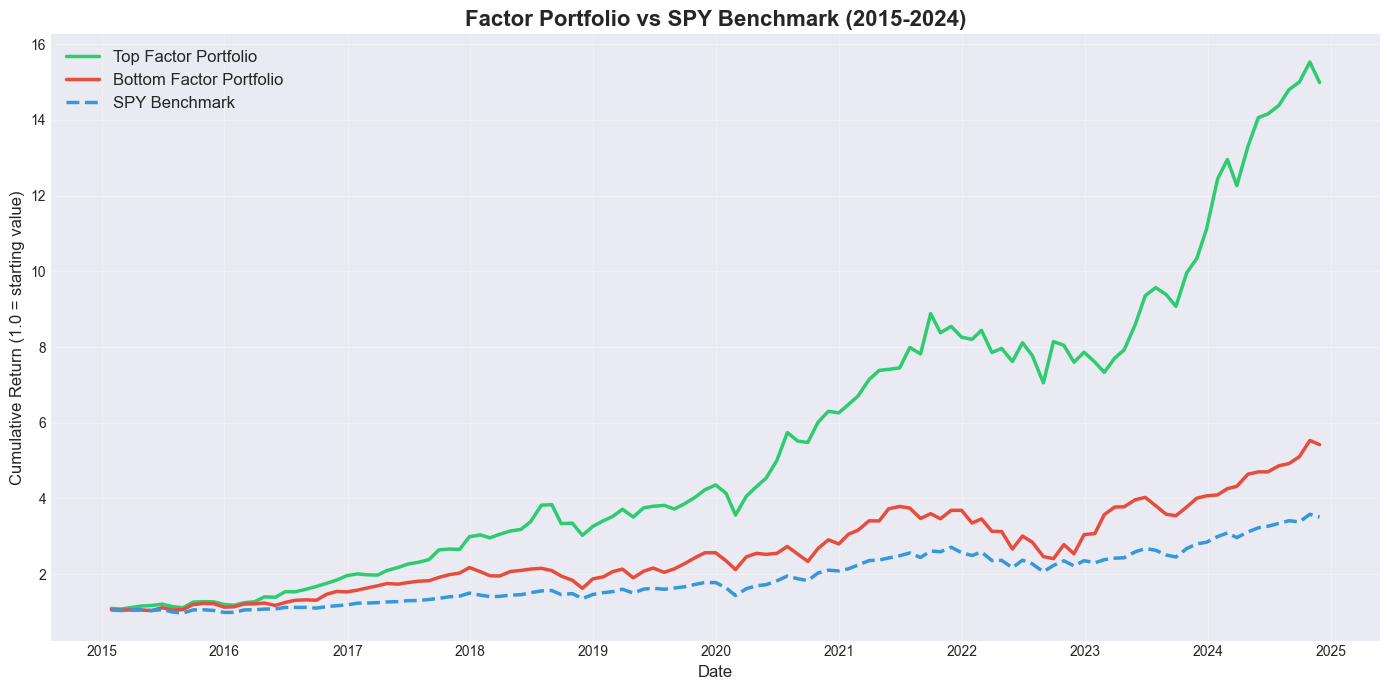

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(backtest_results['date'], backtest_results['cumulative_top'], 
        label='Top Factor Portfolio', color='#2ecc71', linewidth=2.5)
ax.plot(backtest_results['date'], backtest_results['cumulative_bottom'], 
        label='Bottom Factor Portfolio', color='#e74c3c', linewidth=2.5)
ax.plot(backtest_results['date'], backtest_results['cumulative_spy'], 
        label='SPY Benchmark', color='#3498db', linewidth=2.5, linestyle='--')

ax.set_title('Factor Portfolio vs SPY Benchmark (2015-2024)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (1.0 = starting value)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The long portfolio barely did anything special for the first 4 years (2015-2019). Post 2019 is when the returns truly skyrocketed, which generates the question, was the model getting better over time due to more data? Or was it just luck?


In [11]:
def calculate_performance_metrics(returns, name):
    total_return     = (1 + returns).cumprod().iloc[-1] - 1
    ann_return       = (1 + total_return) ** (1/10) - 1
    ann_volatility   = returns.std() * np.sqrt(12)
    sharpe_ratio     = ann_return / ann_volatility
    
    cumulative       = (1 + returns).cumprod()
    rolling_max      = cumulative.cummax()
    drawdown         = (cumulative - rolling_max) / rolling_max
    max_drawdown     = drawdown.min()
    
    win_rate         = (returns > 0).mean()
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Total Return:      {total_return*100:.1f}%")
    print(f"  Annualized Return: {ann_return*100:.1f}%")
    print(f"  Annualized Vol:    {ann_volatility*100:.1f}%")
    print(f"  Sharpe Ratio:      {sharpe_ratio:.3f}")
    print(f"  Max Drawdown:      {max_drawdown*100:.1f}%")
    print(f"  Win Rate:          {win_rate*100:.1f}%")

calculate_performance_metrics(backtest_results['top_return'],    "LONG PORTFOLIO")
calculate_performance_metrics(backtest_results['bottom_return'], "SHORT PORTFOLIO")
calculate_performance_metrics(backtest_results['spy_return'],    "SPY BENCHMARK")


  LONG PORTFOLIO
  Total Return:      1398.7%
  Annualized Return: 31.1%
  Annualized Vol:    19.5%
  Sharpe Ratio:      1.598
  Max Drawdown:      -21.1%
  Win Rate:          68.9%

  SHORT PORTFOLIO
  Total Return:      442.2%
  Annualized Return: 18.4%
  Annualized Vol:    22.3%
  Sharpe Ratio:      0.825
  Max Drawdown:      -36.4%
  Win Rate:          65.5%

  SPY BENCHMARK
  Total Return:      251.0%
  Annualized Return: 13.4%
  Annualized Vol:    15.3%
  Sharpe Ratio:      0.873
  Max Drawdown:      -23.9%
  Win Rate:          69.7%


The results look exceptional: a 1,398% total return, 1.598 Sharpe ratio, and smaller maximum drawdown than SPY suggests the factor model is very successful, however also has limitations and realistic challenges not accounted for. Firstly, survivorship bias: the stocks were handpicked, 15 top ones which already survived and even thrivd the last 10 years. Second, the model did not account for transaction costs. 